# IMC Prosperity 4 — Round 1 Data Analysis
**Products:** `ASH_COATED_OSMIUM` (stable @ 10k) · `INTARIAN_PEPPER_ROOT` (linear trend)

**Currency:** XIRECS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

## 1. Load data
CSVs are **semicolon-delimited** — the KeyError you hit was because `read_csv` defaulted to comma and collapsed all columns into one.

In [2]:
# --- FIX: sep=';' ---
df_prices_day0 = pd.read_csv('prices_round_1_day_0.csv', sep=';')
df_prices_day1 = pd.read_csv('prices_round_1_day_-1.csv', sep=';')
df_prices_day2 = pd.read_csv('prices_round_1_day_-2.csv', sep=';')

df_trades_day0 = pd.read_csv('trades_round_1_day_0.csv', sep=';')
df_trades_day1 = pd.read_csv('trades_round_1_day_-1.csv', sep=';')
df_trades_day2 = pd.read_csv('trades_round_1_day_-2.csv', sep=';')

# Combine & tag each day
for df, tag in [(df_prices_day2, -2), (df_prices_day1, -1), (df_prices_day0, 0)]:
    df['day_offset'] = tag
for df, tag in [(df_trades_day2, -2), (df_trades_day1, -1), (df_trades_day0, 0)]:
    df['day_offset'] = tag

df_prices = pd.concat([df_prices_day2, df_prices_day1, df_prices_day0], ignore_index=True)
df_trades = pd.concat([df_trades_day2, df_trades_day1, df_trades_day0], ignore_index=True)

# Spread
df_prices['spread'] = df_prices['ask_price_1'] - df_prices['bid_price_1']

# Global timestamp for cross-day plotting
df_prices['global_ts'] = (df_prices['day_offset'] + 2) * 1_000_000 + df_prices['timestamp']
df_trades['global_ts'] = (df_trades['day_offset'] + 2) * 1_000_000 + df_trades['timestamp']

products = df_prices['product'].unique()
print('Products:', products)
print(f'Price rows: {len(df_prices):,}')
print(f'Trade rows: {len(df_trades):,}')
print(f"\nColumns: {list(df_prices.columns)}")

Products: <StringArray>
['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
Length: 2, dtype: str
Price rows: 60,000
Trade rows: 2,276

Columns: ['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss', 'day_offset', 'spread', 'global_ts']


## 2. Summary statistics

In [3]:
for prod in products:
    p = df_prices[df_prices['product'] == prod]
    p_valid = p[p['mid_price'] > 0]
    t = df_trades[df_trades['symbol'] == prod]
    print(f'\n{"=" * 50}')
    print(f'{prod}')
    print(f'{"=" * 50}')
    print(f'  Mid price  — mean: {p_valid["mid_price"].mean():.1f}, std: {p_valid["mid_price"].std():.1f}')
    print(f'               min:  {p_valid["mid_price"].min():.1f}, max: {p_valid["mid_price"].max():.1f}')
    print(f'  Spread     — mean: {p["spread"].mean():.1f}, median: {p["spread"].median():.1f}')
    print(f'  Book 1-sided — bid NaN: {p["bid_price_1"].isna().mean()*100:.1f}%, ask NaN: {p["ask_price_1"].isna().mean()*100:.1f}%')
    print(f'  L2 fill rate — {p["bid_price_2"].notna().mean()*100:.1f}%')
    print(f'  Trades     — count: {len(t)}, avg qty: {t["quantity"].mean():.1f}, avg price: {t["price"].mean():.1f}')


INTARIAN_PEPPER_ROOT
  Mid price  — mean: 11499.9, std: 866.1
               min:  9998.5, max: 13007.0
  Spread     — mean: 13.0, median: 13.0
  Book 1-sided — bid NaN: 4.1%, ask NaN: 3.8%
  L2 fill rate — 64.7%
  Trades     — count: 1011, avg qty: 5.2, avg price: 11495.9

ASH_COATED_OSMIUM
  Mid price  — mean: 10000.2, std: 5.3
               min:  9977.0, max: 10023.0
  Spread     — mean: 16.2, median: 16.0
  Book 1-sided — bid NaN: 4.0%, ask NaN: 4.0%
  L2 fill rate — 65.3%
  Trades     — count: 1265, avg qty: 5.2, avg price: 10000.2


## 3. Mid-price time series (all 3 days)

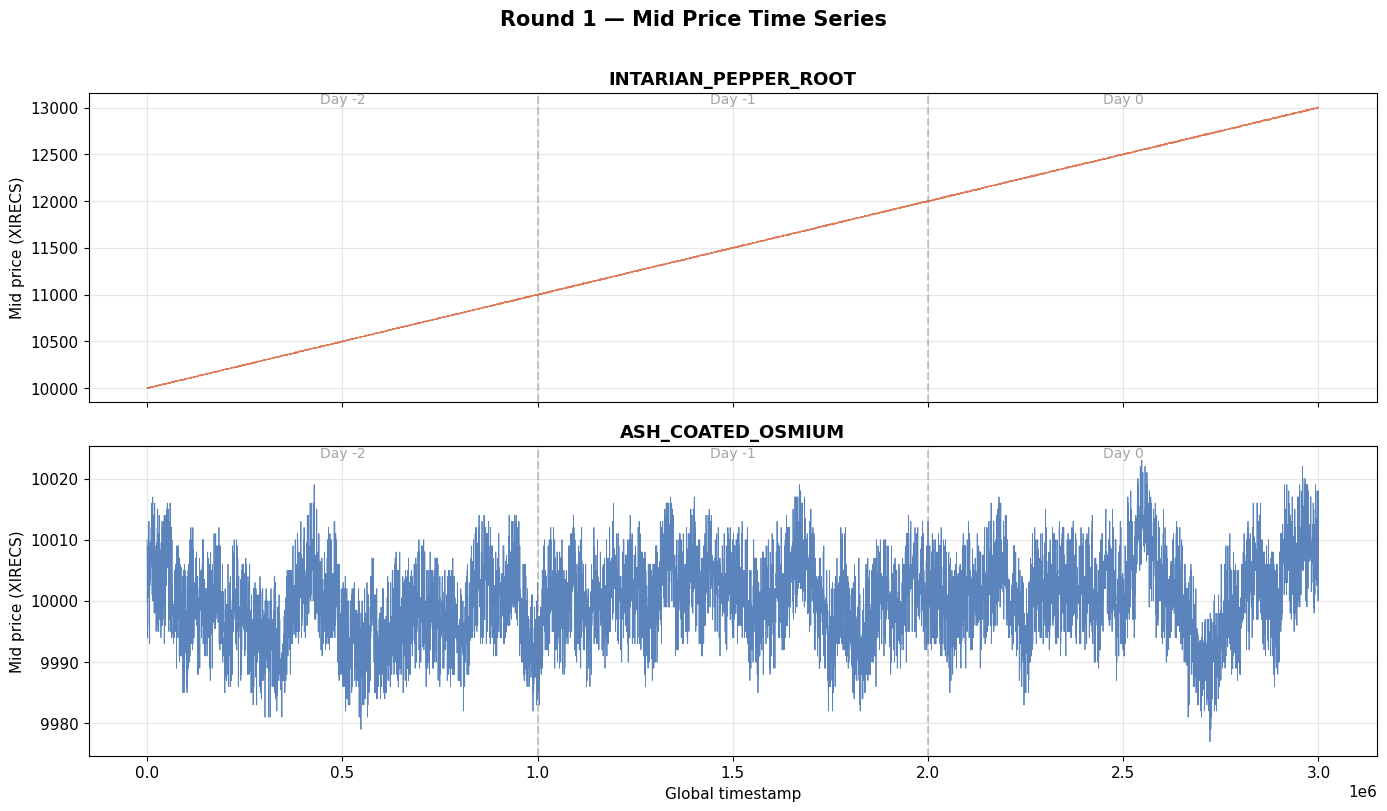

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

colors = {'ASH_COATED_OSMIUM': '#3266ad', 'INTARIAN_PEPPER_ROOT': '#D85A30'}
day_labels = {-2: 'Day -2', -1: 'Day -1', 0: 'Day 0'}

for i, prod in enumerate(products):
    ax = axes[i]
    sub = df_prices[(df_prices['product'] == prod) & (df_prices['mid_price'] > 0)].sort_values('global_ts')
    ax.plot(sub['global_ts'], sub['mid_price'], color=colors[prod], linewidth=0.6, alpha=0.8)
    
    # Day dividers
    for d in [1_000_000, 2_000_000]:
        ax.axvline(d, color='gray', linestyle='--', alpha=0.4)
    
    ax.set_title(prod, fontweight='bold', fontsize=13)
    ax.set_ylabel('Mid price (XIRECS)')
    
    # Add day labels
    for d_off, label in day_labels.items():
        x_pos = (d_off + 2) * 1_000_000 + 500_000
        ax.text(x_pos, ax.get_ylim()[1] if i == 0 else ax.get_ylim()[1], label,
                ha='center', va='top', fontsize=10, color='gray', alpha=0.7)

axes[-1].set_xlabel('Global timestamp')
plt.suptitle('Round 1 — Mid Price Time Series', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. ASH_COATED_OSMIUM — stable fair value at 10,000
This is the classic market-making product. Fair value is pinned at 10,000.

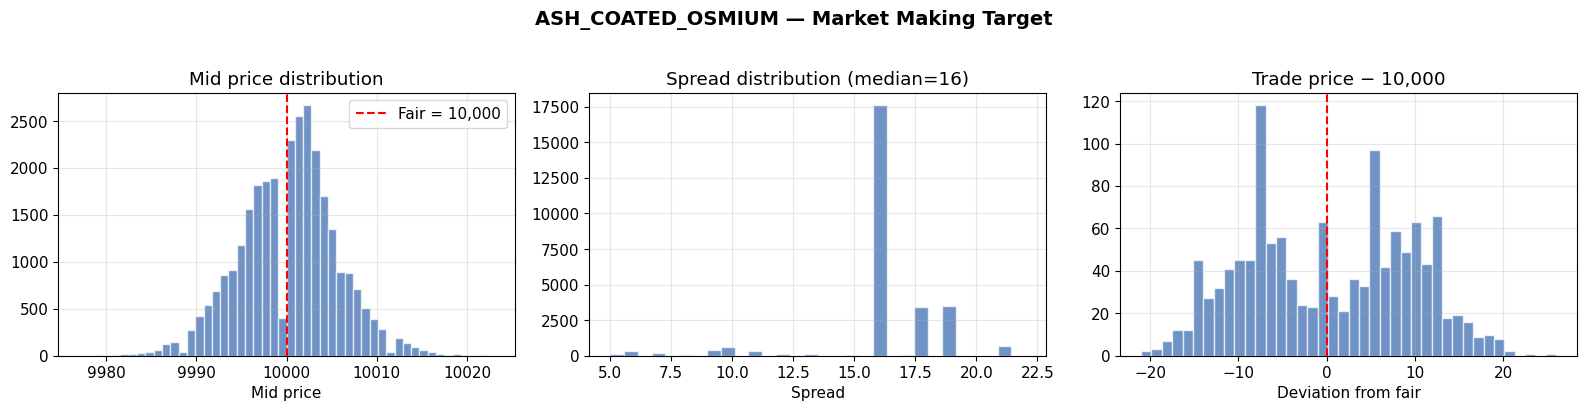


94.4% of mid prices are within ±10 of 10,000
Trade price std from 10k: 9.4


In [5]:
aco = df_prices[(df_prices['product'] == 'ASH_COATED_OSMIUM') & (df_prices['mid_price'] > 0)].copy()
aco_trades = df_trades[df_trades['symbol'] == 'ASH_COATED_OSMIUM'].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Mid price histogram
axes[0].hist(aco['mid_price'], bins=50, color='#3266ad', alpha=0.7, edgecolor='white')
axes[0].axvline(10000, color='red', linestyle='--', linewidth=1.5, label='Fair = 10,000')
axes[0].set_title('Mid price distribution')
axes[0].set_xlabel('Mid price')
axes[0].legend()

# Spread histogram
spread_valid = aco['spread'].dropna()
axes[1].hist(spread_valid, bins=30, color='#3266ad', alpha=0.7, edgecolor='white')
axes[1].set_title(f'Spread distribution (median={spread_valid.median():.0f})')
axes[1].set_xlabel('Spread')

# Trade price vs fair value
axes[2].hist(aco_trades['price'] - 10000, bins=40, color='#3266ad', alpha=0.7, edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Trade price − 10,000')
axes[2].set_xlabel('Deviation from fair')

plt.suptitle('ASH_COATED_OSMIUM — Market Making Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n94.4% of mid prices are within ±10 of 10,000')
print(f'Trade price std from 10k: {(aco_trades["price"] - 10000).std():.1f}')

## 5. INTARIAN_PEPPER_ROOT — deterministic linear trend
Fair value = `10000 + 1000*day_offset + 0.001*timestamp`

Slope is exactly 0.001 per tick across all 3 days. Residual std ≈ 2.2.

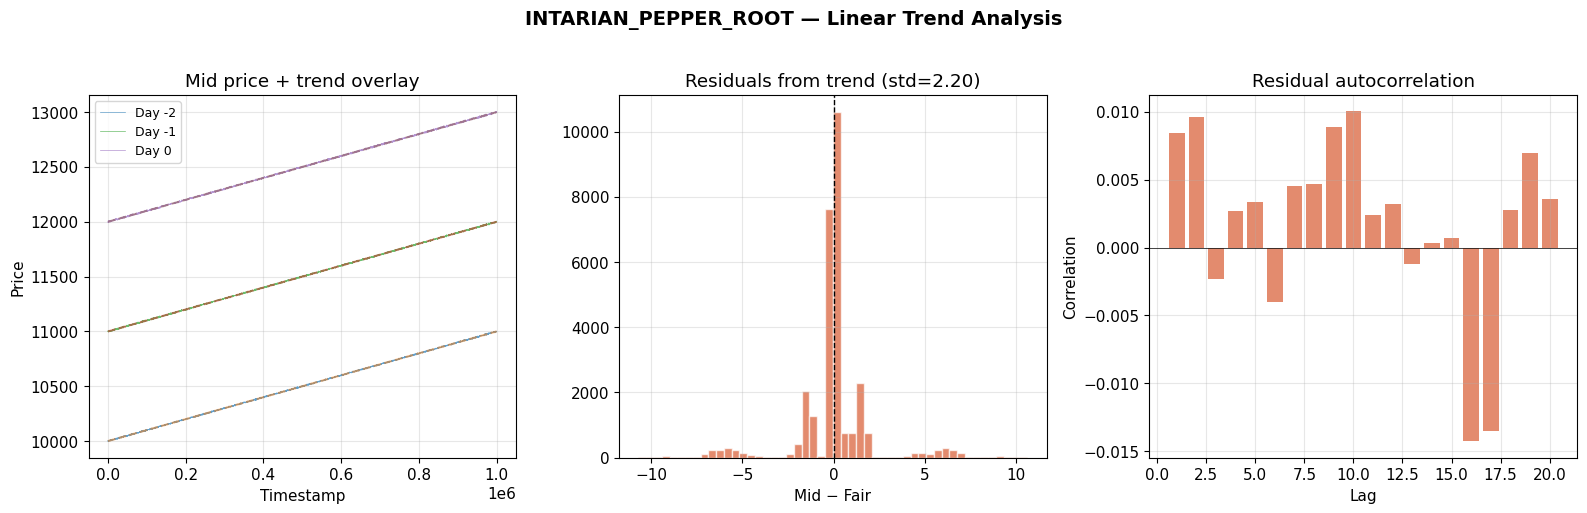


Trend fit per day:
  Day -2: slope=0.001000/tick, intercept=10000.0, residual_std=2.01
  Day -1: slope=0.001000/tick, intercept=11000.0, residual_std=2.22
  Day +0: slope=0.001000/tick, intercept=12000.0, residual_std=2.36


In [6]:
ipr = df_prices[(df_prices['product'] == 'INTARIAN_PEPPER_ROOT') & (df_prices['mid_price'] > 0)].copy()
ipr_trades = df_trades[df_trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Per-day trend fit
day_bases = {-2: 10000, -1: 11000, 0: 12000}
all_residuals = []

for d_off in [-2, -1, 0]:
    sub = ipr[ipr['day_offset'] == d_off].sort_values('timestamp')
    fair = day_bases[d_off] + 0.001 * sub['timestamp']
    residuals = sub['mid_price'] - fair
    all_residuals.extend(residuals.values)
    
    label = f'Day {d_off}'
    axes[0].plot(sub['timestamp'], sub['mid_price'], linewidth=0.5, alpha=0.7, label=label)
    axes[0].plot(sub['timestamp'], fair, '--', linewidth=1.5, alpha=0.5)

axes[0].set_title('Mid price + trend overlay')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Price')
axes[0].legend(fontsize=9)

# Residuals histogram
axes[1].hist(all_residuals, bins=50, color='#D85A30', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title(f'Residuals from trend (std={np.std(all_residuals):.2f})')
axes[1].set_xlabel('Mid − Fair')

# Residual autocorrelation
res_arr = np.array(all_residuals)
lags = range(1, 21)
autocorrs = [np.corrcoef(res_arr[:-l], res_arr[l:])[0, 1] for l in lags]
axes[2].bar(lags, autocorrs, color='#D85A30', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Residual autocorrelation')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('Correlation')

plt.suptitle('INTARIAN_PEPPER_ROOT — Linear Trend Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Confirm slope per day
print('\nTrend fit per day:')
for d_off in [-2, -1, 0]:
    sub = ipr[ipr['day_offset'] == d_off].sort_values('timestamp')
    slope, intercept = np.polyfit(sub['timestamp'], sub['mid_price'], 1)
    res = sub['mid_price'] - (slope * sub['timestamp'] + intercept)
    print(f'  Day {d_off:+d}: slope={slope:.6f}/tick, intercept={intercept:.1f}, residual_std={res.std():.2f}')

## 6. Order book depth & trade analysis

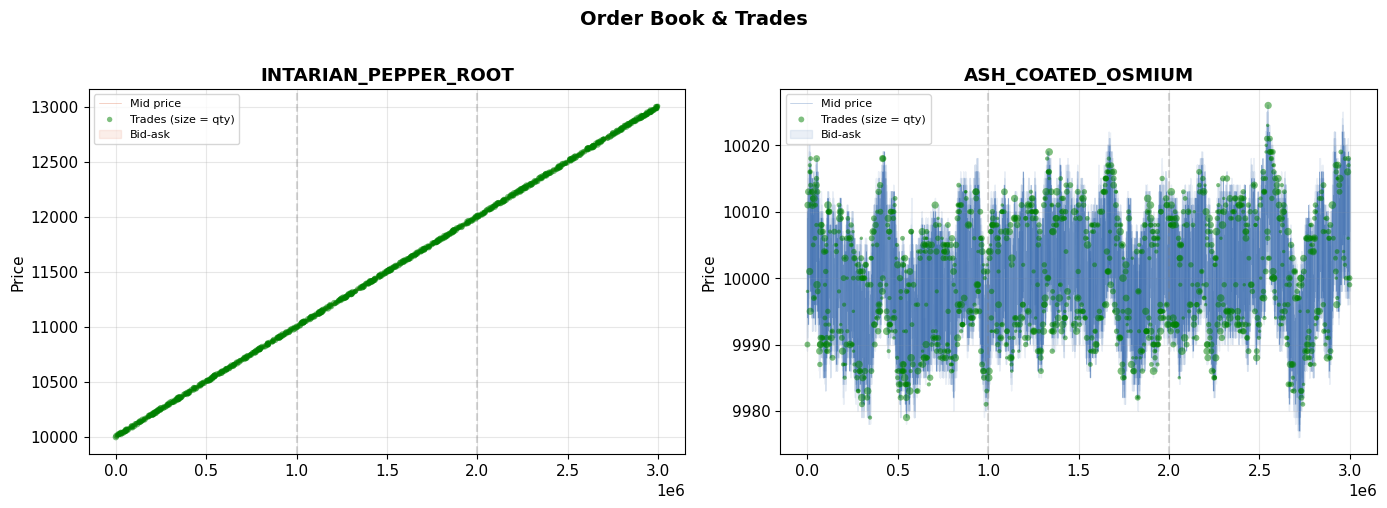

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, prod in enumerate(products):
    t = df_trades[df_trades['symbol'] == prod]
    p = df_prices[(df_prices['product'] == prod) & (df_prices['mid_price'] > 0)].sort_values('global_ts')
    
    ax = axes[i]
    ax.plot(p['global_ts'], p['mid_price'], color=colors[prod], linewidth=0.4, alpha=0.5, label='Mid price')
    ax.scatter(t['global_ts'], t['price'], s=t['quantity'] * 3, alpha=0.5,
              color='green', edgecolors='none', label='Trades (size = qty)', zorder=5)
    
    # Bid/ask envelope
    ax.fill_between(p['global_ts'], p['bid_price_1'], p['ask_price_1'],
                    alpha=0.1, color=colors[prod], label='Bid-ask')
    
    ax.set_title(prod, fontweight='bold')
    ax.set_ylabel('Price')
    ax.legend(fontsize=8, loc='upper left')
    
    for d in [1_000_000, 2_000_000]:
        ax.axvline(d, color='gray', linestyle='--', alpha=0.3)

plt.suptitle('Order Book & Trades', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Trade quantity & timing distributions

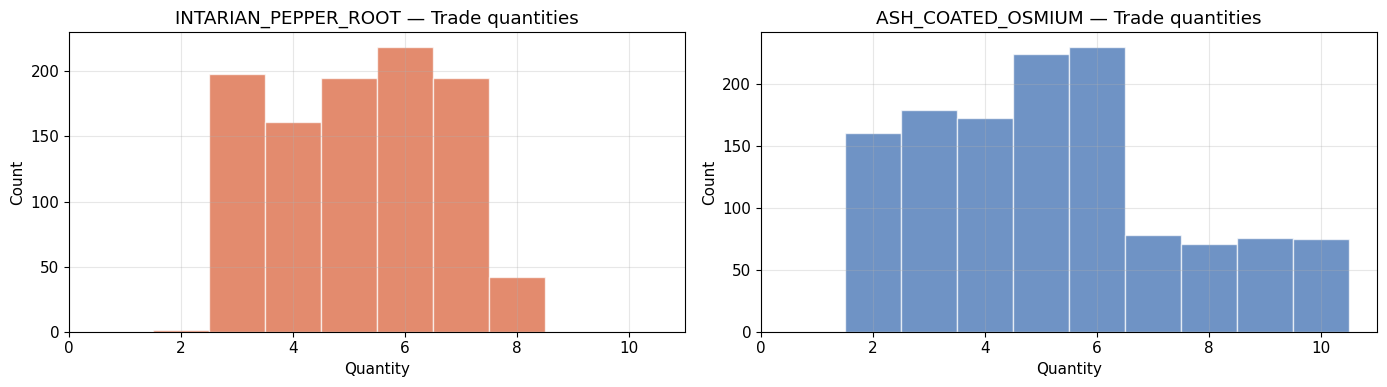

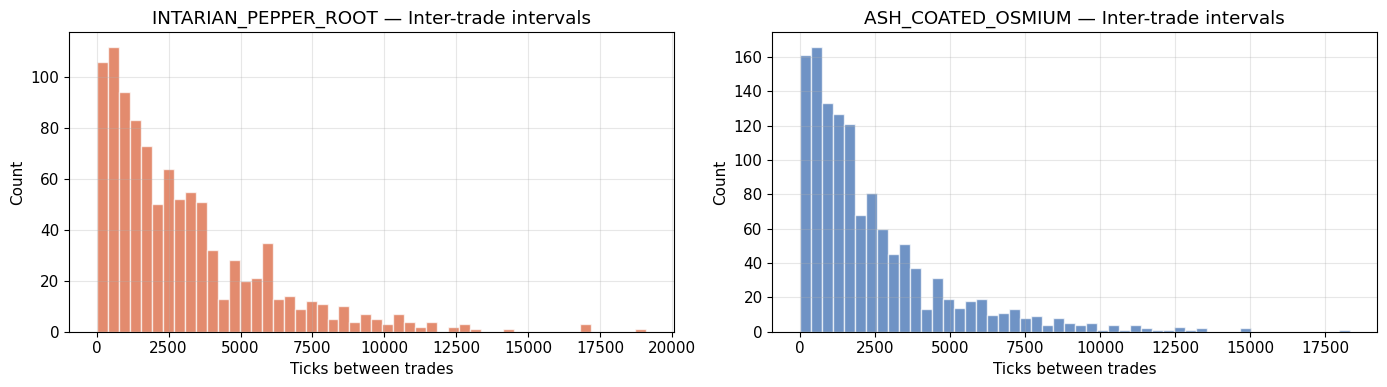

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, prod in enumerate(products):
    t = df_trades[df_trades['symbol'] == prod]
    axes[i].hist(t['quantity'], bins=range(1, 12), color=colors[prod], alpha=0.7,
                edgecolor='white', align='left')
    axes[i].set_title(f'{prod} — Trade quantities')
    axes[i].set_xlabel('Quantity')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Inter-trade timing
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, prod in enumerate(products):
    t = df_trades[df_trades['symbol'] == prod].sort_values('global_ts')
    dt = t['global_ts'].diff().dropna()
    axes[i].hist(dt[dt < 20000], bins=50, color=colors[prod], alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{prod} — Inter-trade intervals')
    axes[i].set_xlabel('Ticks between trades')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 8. Strategy notes

### ASH_COATED_OSMIUM
- **Fair value = 10,000** (fixed, std ≈ 5)
- Market-make around 10k: bid ~9,992–9,995, ask ~10,005–10,008
- Skew quotes based on inventory to mean-revert position
- Book is one-sided ~4% of ticks — can hit aggressive orders

### INTARIAN_PEPPER_ROOT
- **Fair = base + 0.001 × timestamp** (base increases +1000/day)
- Residual std ≈ 2.2, returns autocorr = –0.51 (strong mean reversion)
- Market-make around computed fair with tight spreads
- Key question: will the trend slope/base hold on actual evaluation day?

## 9. INTARIAN_PEPPER_ROOT — Variance & Standard Deviation

In [9]:
ipr_valid = df_prices[(df_prices['product'] == 'INTARIAN_PEPPER_ROOT') & (df_prices['mid_price'] > 0)].copy()

print('INTARIAN_PEPPER_ROOT — Mid Price Variance & Standard Deviation')
print('=' * 60)

# Overall
overall_var = ipr_valid['mid_price'].var()
overall_std = ipr_valid['mid_price'].std()
print(f'\nOverall (all 3 days):')
print(f'  Variance : {overall_var:,.2f}')
print(f'  Std Dev  : {overall_std:,.2f}')

# Per-day breakdown
print(f'\nPer-day breakdown:')
for d in [-2, -1, 0]:
    sub = ipr_valid[ipr_valid['day_offset'] == d]['mid_price']
    print(f'  Day {d:+d}  — Variance: {sub.var():,.2f}  |  Std Dev: {sub.std():,.2f}')

# Detrended residuals
day_bases = {-2: 10000, -1: 11000, 0: 12000}
ipr_valid['fair_value'] = ipr_valid.apply(
    lambda r: day_bases[r['day_offset']] + 0.001 * r['timestamp'], axis=1
)
ipr_valid['residual'] = ipr_valid['mid_price'] - ipr_valid['fair_value']

res_var = ipr_valid['residual'].var()
res_std = ipr_valid['residual'].std()
print(f'\nDetrended residuals (mid − fair_value):')
print(f'  Variance : {res_var:.4f}')
print(f'  Std Dev  : {res_std:.4f}')

INTARIAN_PEPPER_ROOT — Mid Price Variance & Standard Deviation

Overall (all 3 days):
  Variance : 750,141.58
  Std Dev  : 866.11

Per-day breakdown:
  Day -2  — Variance: 83,360.61  |  Std Dev: 288.72
  Day -1  — Variance: 83,329.80  |  Std Dev: 288.67
  Day +0  — Variance: 83,365.58  |  Std Dev: 288.73

Detrended residuals (mid − fair_value):
  Variance : 4.8461
  Std Dev  : 2.2014


## 10. INTARIAN_PEPPER_ROOT — Zoomed per-day market view
Strip the linear trend and zoom into each day to see intraday spread, bid-ask, and trades.

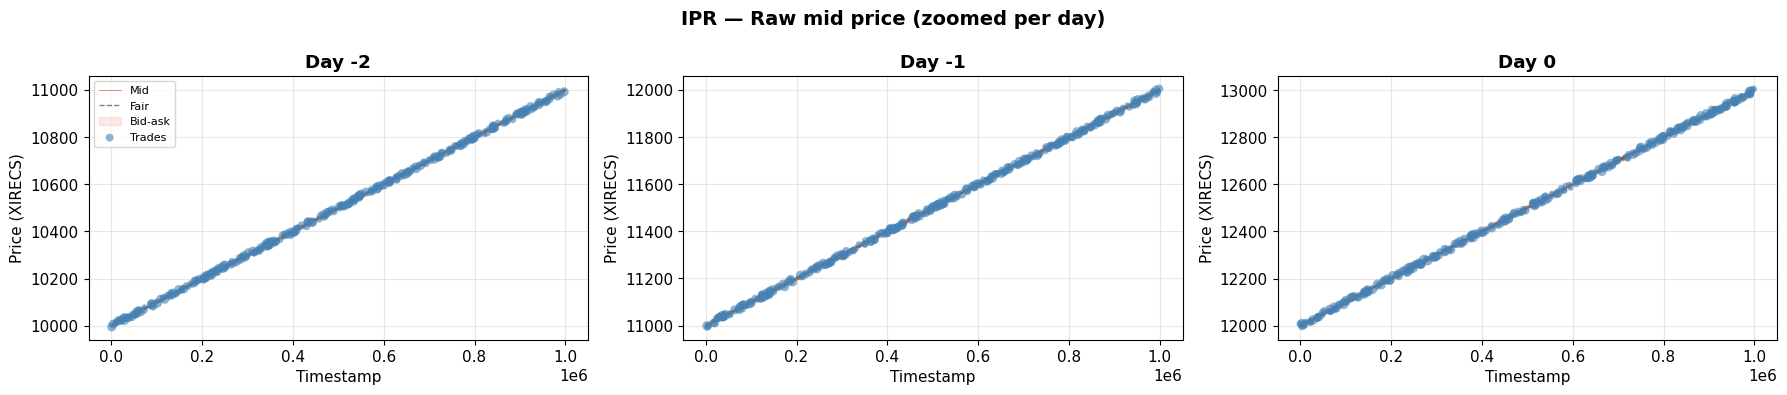

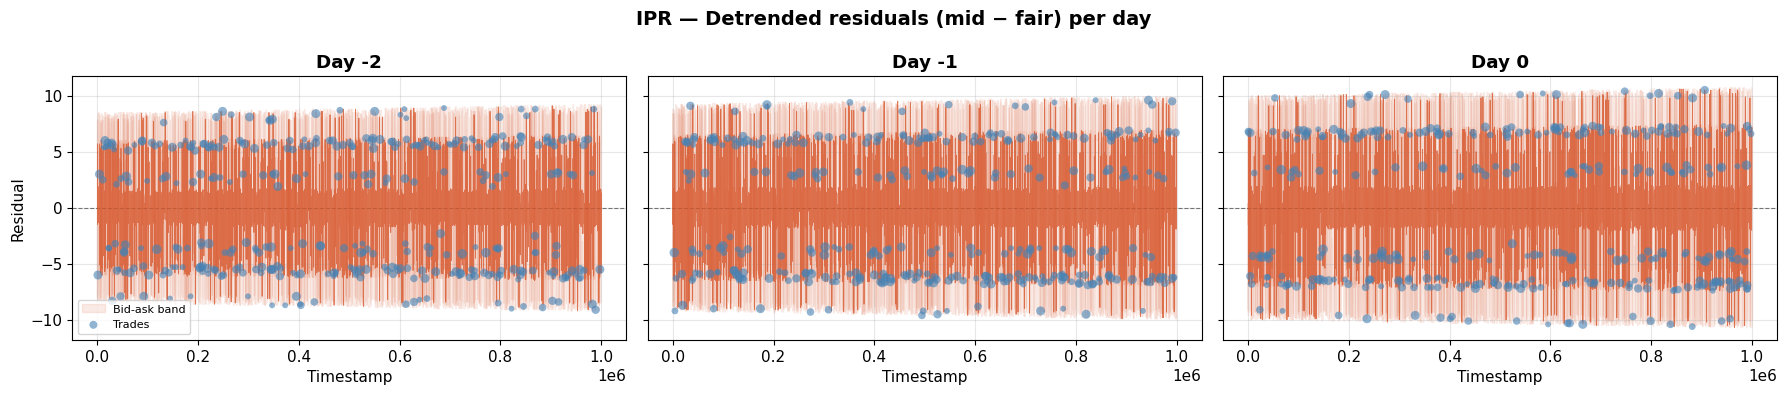

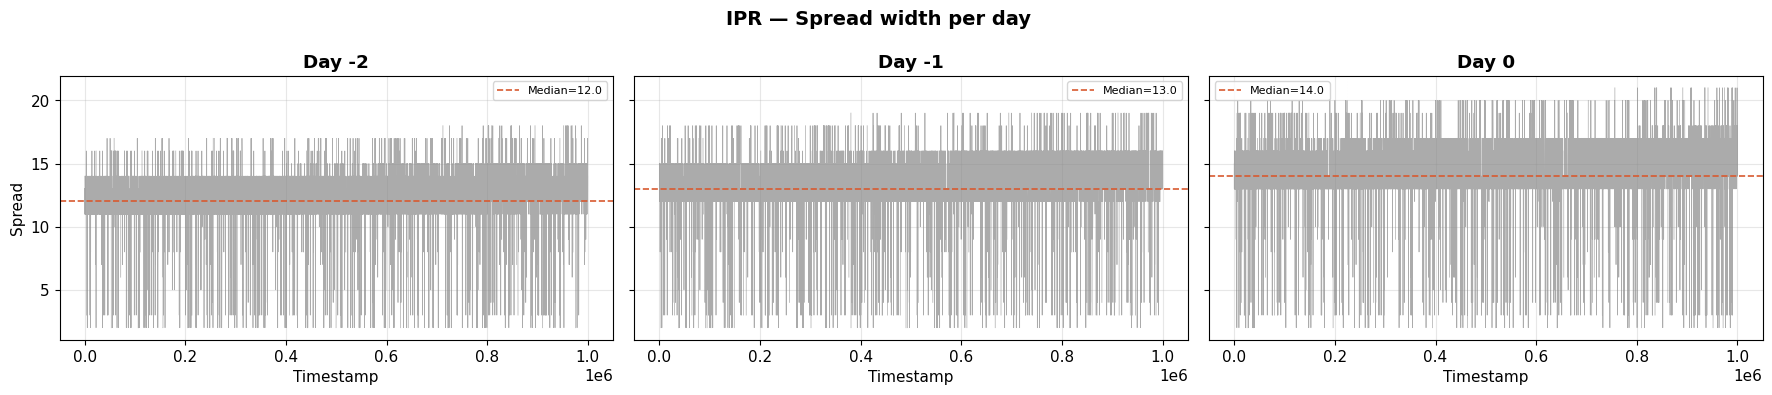

In [10]:
day_bases = {-2: 10000, -1: 11000, 0: 12000}
day_labels_map = {-2: "Day -2", -1: "Day -1", 0: "Day 0"}

ipr_all = df_prices[
    (df_prices["product"] == "INTARIAN_PEPPER_ROOT") & (df_prices["mid_price"] > 0)
].copy()
ipr_all["fair"] = ipr_all.apply(lambda r: day_bases[r["day_offset"]] + 0.001 * r["timestamp"], axis=1)
ipr_all["residual"] = ipr_all["mid_price"] - ipr_all["fair"]

ipr_t = df_trades[df_trades["symbol"] == "INTARIAN_PEPPER_ROOT"].copy()
ipr_t["fair"] = ipr_t.apply(lambda r: day_bases[r["day_offset"]] + 0.001 * r["timestamp"], axis=1)
ipr_t["residual"] = ipr_t["price"] - ipr_t["fair"]

# ── Row 1: raw mid price per day (zoomed y-axis) ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
fig.suptitle("IPR — Raw mid price (zoomed per day)", fontsize=14, fontweight="bold")

for ax, d in zip(axes, [-2, -1, 0]):
    sub = ipr_all[ipr_all["day_offset"] == d].sort_values("timestamp")
    t_sub = ipr_t[ipr_t["day_offset"] == d]
    fair_line = day_bases[d] + 0.001 * sub["timestamp"]

    ax.plot(sub["timestamp"], sub["mid_price"], color="#D85A30", linewidth=0.6, alpha=0.8, label="Mid")
    ax.plot(sub["timestamp"], fair_line, "--", color="black", linewidth=1.0, alpha=0.5, label="Fair")
    ax.fill_between(sub["timestamp"], sub["bid_price_1"], sub["ask_price_1"],
                    alpha=0.12, color="#D85A30", label="Bid-ask")
    ax.scatter(t_sub["timestamp"], t_sub["price"],
               s=t_sub["quantity"] * 6, color="steelblue", alpha=0.6, zorder=5,
               edgecolors="none", label="Trades")
    ax.set_title(day_labels_map[d], fontweight="bold")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Price (XIRECS)")
    if d == -2:
        ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

# ── Row 2: detrended residuals per day ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
fig.suptitle("IPR — Detrended residuals (mid − fair) per day", fontsize=14, fontweight="bold")

for ax, d in zip(axes, [-2, -1, 0]):
    sub = ipr_all[ipr_all["day_offset"] == d].sort_values("timestamp")
    t_sub = ipr_t[ipr_t["day_offset"] == d]

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.plot(sub["timestamp"], sub["residual"], color="#D85A30", linewidth=0.6, alpha=0.8)
    spread_half = sub["spread"] / 2
    ax.fill_between(sub["timestamp"],
                    sub["bid_price_1"] - sub["fair"],
                    sub["ask_price_1"] - sub["fair"],
                    alpha=0.12, color="#D85A30", label="Bid-ask band")
    ax.scatter(t_sub["timestamp"], t_sub["residual"],
               s=t_sub["quantity"] * 6, color="steelblue", alpha=0.6, zorder=5,
               edgecolors="none", label="Trades")
    ax.set_title(day_labels_map[d], fontweight="bold")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Residual" if d == -2 else "")
    if d == -2:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Row 3: spread and bid/ask depth per day ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
fig.suptitle("IPR — Spread width per day", fontsize=14, fontweight="bold")

for ax, d in zip(axes, [-2, -1, 0]):
    sub = ipr_all[ipr_all["day_offset"] == d].sort_values("timestamp")
    spread = sub["spread"].dropna()

    ax.plot(sub["timestamp"], sub["spread"], color="#888", linewidth=0.5, alpha=0.7)
    ax.axhline(spread.median(), color="#D85A30", linewidth=1.2, linestyle="--",
               label=f"Median={spread.median():.1f}")
    ax.set_title(day_labels_map[d], fontweight="bold")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Spread" if d == -2 else "")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 11. ASH_COATED_OSMIUM — Mid price vs Spread (all 3 days)
Dual-axis overlay: mid price (left) and spread (right). Day dividers mark day boundaries. Does spread widen when price deviates from 10k?

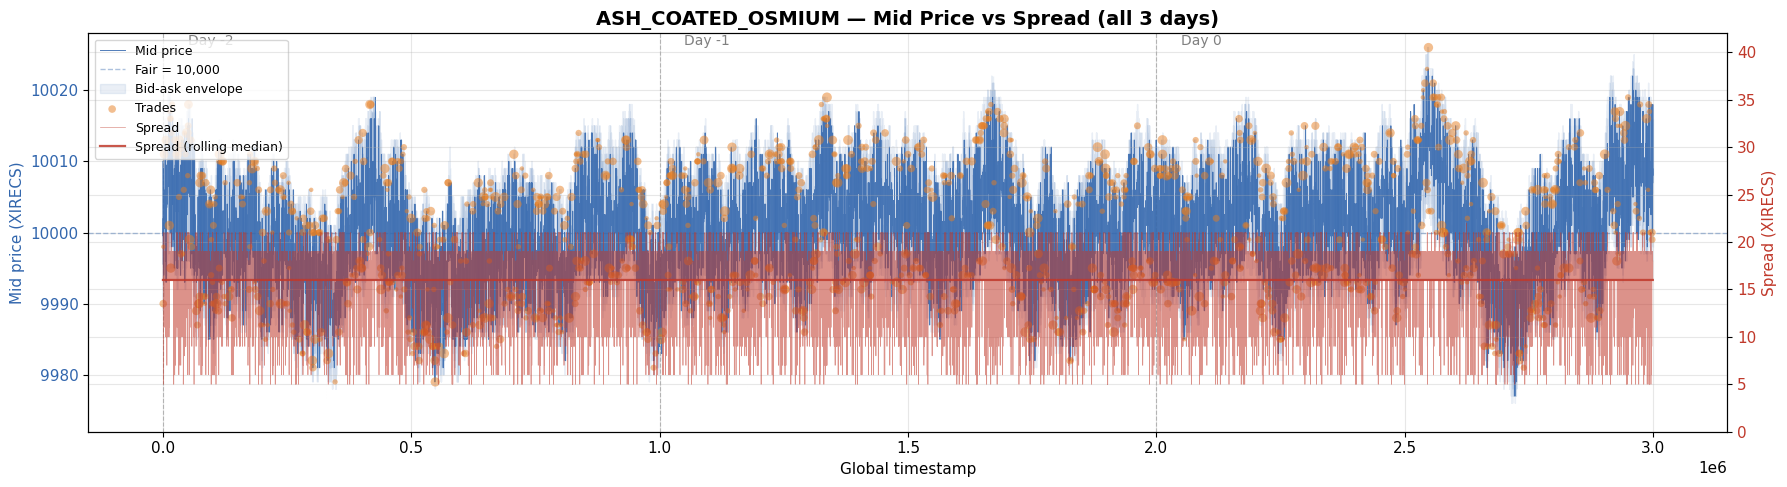

Pearson corr(spread, |mid - 10000|) = -0.0939
Spread median: 16.0  |  std: 2.57
Price deviation from 10k — median: 3.00  |  std: 2.96


In [11]:
aco_all = df_prices[
    (df_prices["product"] == "ASH_COATED_OSMIUM") & (df_prices["mid_price"] > 0)
].sort_values("global_ts").copy()

aco_t = df_trades[df_trades["symbol"] == "ASH_COATED_OSMIUM"].copy()

fig, ax1 = plt.subplots(figsize=(18, 5))

# ── Mid price (left axis) ──────────────────────────────────────────────────
ax1.plot(aco_all["global_ts"], aco_all["mid_price"],
         color="#3266ad", linewidth=0.7, alpha=0.85, label="Mid price", zorder=3)
ax1.axhline(10000, color="#3266ad", linestyle="--", linewidth=1.0, alpha=0.4, label="Fair = 10,000")

# Shade bid-ask envelope around mid
ax1.fill_between(aco_all["global_ts"],
                 aco_all["bid_price_1"], aco_all["ask_price_1"],
                 alpha=0.10, color="#3266ad", label="Bid-ask envelope")

# Trade dots
ax1.scatter(aco_t["global_ts"], aco_t["price"],
            s=aco_t["quantity"] * 5, color="#e67e22", alpha=0.5,
            edgecolors="none", zorder=5, label="Trades")

ax1.set_ylabel("Mid price (XIRECS)", color="#3266ad")
ax1.tick_params(axis="y", labelcolor="#3266ad")
ax1.set_ylim(aco_all["mid_price"].min() - 5, aco_all["mid_price"].max() + 5)

# ── Spread (right axis) ────────────────────────────────────────────────────
ax2 = ax1.twinx()
spread_valid = aco_all.dropna(subset=["spread"])
ax2.plot(spread_valid["global_ts"], spread_valid["spread"],
         color="#c0392b", linewidth=0.5, alpha=0.55, label="Spread")
# Rolling median to smooth the spread signal
spread_roll = spread_valid["spread"].rolling(200, center=True, min_periods=1).median()
ax2.plot(spread_valid["global_ts"], spread_roll,
         color="#c0392b", linewidth=1.6, alpha=0.85, label="Spread (rolling median)")

ax2.set_ylabel("Spread (XIRECS)", color="#c0392b")
ax2.tick_params(axis="y", labelcolor="#c0392b")
ax2.set_ylim(0, spread_valid["spread"].quantile(0.99) * 2)

# ── Day dividers & labels ──────────────────────────────────────────────────
day_starts = {"Day -2": 0, "Day -1": 1_000_000, "Day 0": 2_000_000}
for label, x in day_starts.items():
    ax1.axvline(x, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax1.text(x + 50_000, aco_all["mid_price"].max() + 3, label,
             fontsize=10, color="gray", va="bottom")

# ── Legends ────────────────────────────────────────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_xlabel("Global timestamp")
ax1.set_title("ASH_COATED_OSMIUM — Mid Price vs Spread (all 3 days)",
              fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

# ── Correlation check ──────────────────────────────────────────────────────
merged = aco_all.dropna(subset=["spread", "mid_price"]).copy()
merged["dev_from_fair"] = (merged["mid_price"] - 10000).abs()
corr = merged[["spread", "dev_from_fair"]].corr().iloc[0, 1]
print(f"Pearson corr(spread, |mid - 10000|) = {corr:.4f}")
print(f"Spread median: {merged['spread'].median():.1f}  |  std: {merged['spread'].std():.2f}")
print(f"Price deviation from 10k — median: {merged['dev_from_fair'].median():.2f}  |  std: {merged['dev_from_fair'].std():.2f}")


## 12. ASH_COATED_OSMIUM — Price & Spread per trading day
One column per day: mid price with bid-ask envelope and trade dots (top row), spread over time (bottom row).

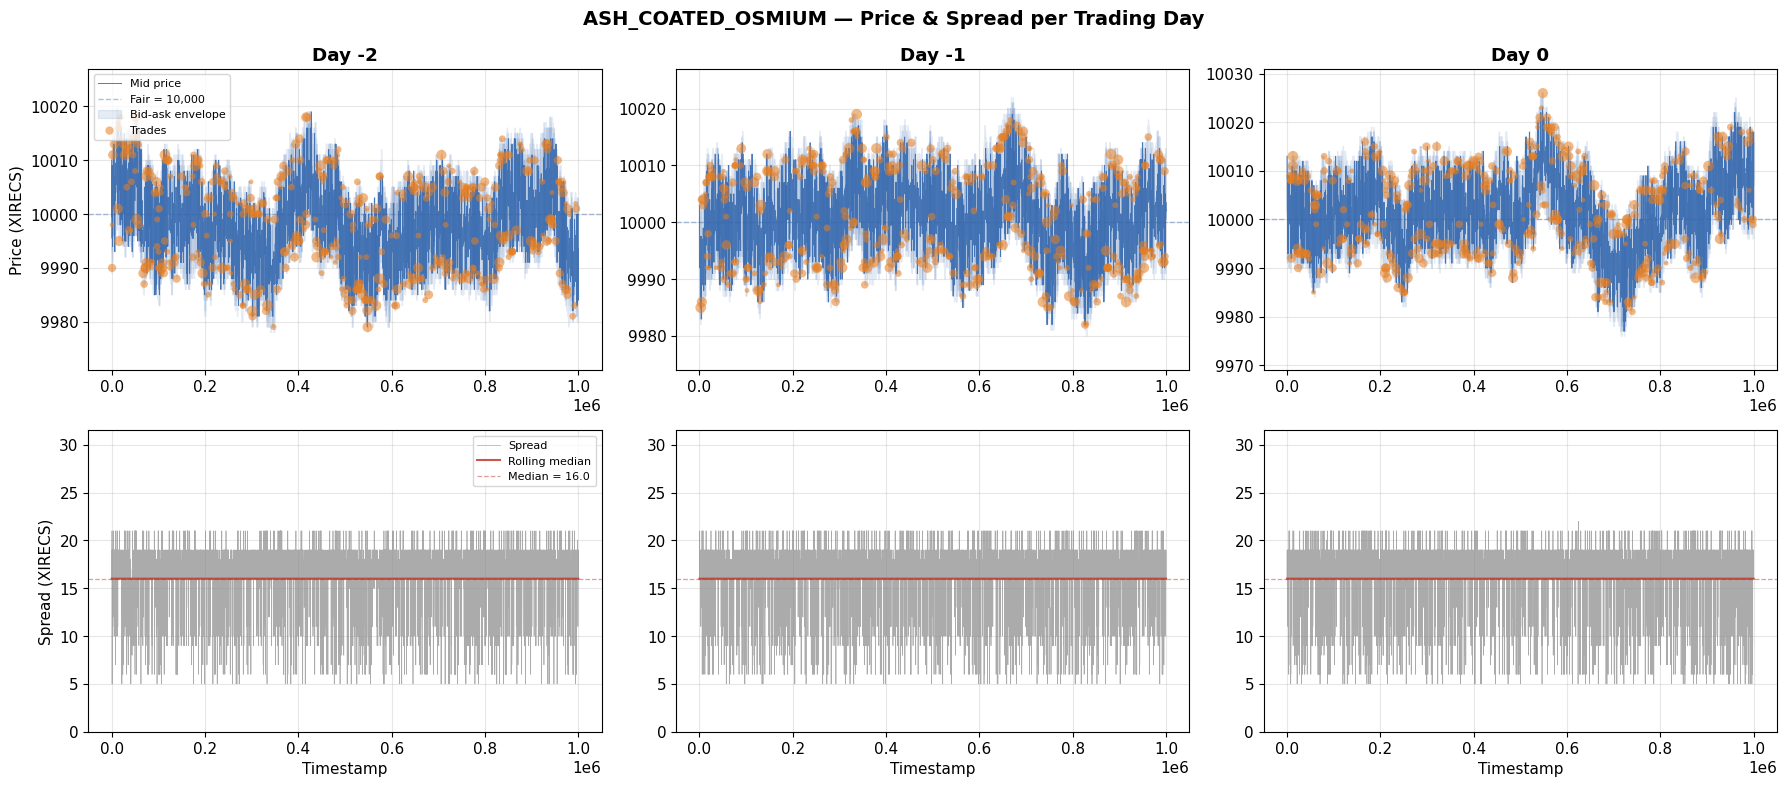

ACO — per-day price & spread summary
  Day -2    mid mean=9998.17  mid std=5.22  spread median=16.0  spread std=2.54
  Day -1    mid mean=10000.83  mid std=4.45  spread median=16.0  spread std=2.56
  Day 0     mid mean=10001.61  mid std=5.68  spread median=16.0  spread std=2.62


In [12]:
aco_days = df_prices[
    (df_prices["product"] == "ASH_COATED_OSMIUM") & (df_prices["mid_price"] > 0)
].copy()
aco_t_days = df_trades[df_trades["symbol"] == "ASH_COATED_OSMIUM"].copy()

day_labels_map = {-2: "Day -2", -1: "Day -1", 0: "Day 0"}

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False)
fig.suptitle("ASH_COATED_OSMIUM — Price & Spread per Trading Day",
             fontsize=14, fontweight="bold")

for col, d in enumerate([-2, -1, 0]):
    sub = aco_days[aco_days["day_offset"] == d].sort_values("timestamp")
    t_sub = aco_t_days[aco_t_days["day_offset"] == d]
    spread_valid = sub.dropna(subset=["spread"])

    # ── Row 0: mid price ──────────────────────────────────────────────────
    ax_p = axes[0, col]
    ax_p.plot(sub["timestamp"], sub["mid_price"],
              color="#3266ad", linewidth=0.7, alpha=0.85, label="Mid price")
    ax_p.axhline(10000, color="#3266ad", linestyle="--", linewidth=1.0,
                 alpha=0.4, label="Fair = 10,000")
    ax_p.fill_between(sub["timestamp"], sub["bid_price_1"], sub["ask_price_1"],
                      alpha=0.12, color="#3266ad", label="Bid-ask envelope")
    ax_p.scatter(t_sub["timestamp"], t_sub["price"],
                 s=t_sub["quantity"] * 6, color="#e67e22", alpha=0.55,
                 edgecolors="none", zorder=5, label="Trades")
    ax_p.set_title(day_labels_map[d], fontweight="bold")
    ax_p.set_ylabel("Price (XIRECS)" if col == 0 else "")
    ax_p.set_ylim(sub["mid_price"].min() - 8, sub["mid_price"].max() + 8)
    if col == 0:
        ax_p.legend(fontsize=8, loc="upper left")

    # ── Row 1: spread ─────────────────────────────────────────────────────
    ax_s = axes[1, col]
    ax_s.plot(spread_valid["timestamp"], spread_valid["spread"],
              color="#888", linewidth=0.5, alpha=0.7, label="Spread")
    roll = spread_valid["spread"].rolling(200, center=True, min_periods=1).median()
    ax_s.plot(spread_valid["timestamp"], roll,
              color="#c0392b", linewidth=1.5, alpha=0.85, label=f"Rolling median")
    ax_s.axhline(spread_valid["spread"].median(), color="#c0392b",
                 linestyle="--", linewidth=0.9, alpha=0.5,
                 label=f"Median = {spread_valid['spread'].median():.1f}")
    ax_s.set_xlabel("Timestamp")
    ax_s.set_ylabel("Spread (XIRECS)" if col == 0 else "")
    ax_s.set_ylim(0, spread_valid["spread"].quantile(0.99) * 1.5)
    if col == 0:
        ax_s.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Per-day summary ────────────────────────────────────────────────────────
print("ACO — per-day price & spread summary")
print("=" * 55)
for d in [-2, -1, 0]:
    sub = aco_days[aco_days["day_offset"] == d]
    sp = sub["spread"].dropna()
    print(f"  {day_labels_map[d]:8s}  mid mean={sub['mid_price'].mean():.2f}  "
          f"mid std={sub['mid_price'].std():.2f}  "
          f"spread median={sp.median():.1f}  spread std={sp.std():.2f}")